# Prediccion de redshift con CatBoost

Se predice el redshift espectroscopico a partir de features fotometricas del catalogo DESI Legacy Imaging Survey.

Diferencias respecto al notebook con Random Forest:
- CatBoost maneja variables categoricas nativamente (no necesita OneHotEncoder)
- CatBoost maneja NaN nativamente (no necesita SimpleImputer)
- No se necesita StandardScaler (modelos basados en arboles son invariantes a escala)
- Al no hacer `dropna` sobre features, se conservan mas datos de entrenamiento

Estructura:
1. Ingenieria de features
2. Split train/val/test 60/20/20, con test reservado hasta el final
3. Modelo dummy como baseline
4. CatBoost con hiperparametros por defecto
5. Optimizacion de hiperparametros (Optuna, CV sobre train)
6. PFI sobre modelo optimizado para seleccionar features
7. Re-entrenamiento con features seleccionadas
8. Evaluacion final en test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_features()
df.shape

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


(21287, 80)

## Ingenieria de features

1. Magnitudes corregidas por extincion galactica en bandas WISE (W1-W4)
2. Flujos de apertura corregidos y sus magnitudes (bandas g, r, i, z)
3. Colores a partir de magnitudes corregidas

In [3]:
# Magnitudes WISE corregidas por extincion galactica
bands_wise = ["w1", "w2", "w3", "w4"]

for band in bands_wise:
    df["flux_" + band + "_corr"] = df["flux_" + band] / df["mw_transmission_" + band]
    df["mag_" + band + "_corr"] = 22.5 - 2.5 * np.log10(df["flux_" + band + "_corr"])

/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
# Flujos de apertura corregidos y magnitudes (bandas opticas)
bands_optical = ['g', 'r', 'i', 'z']

for band in bands_optical:
    trans = df[f'mw_transmission_{band}']
    apcols = [c for c in df.columns if c.startswith(f'apflux_{band}_')]
    for col in apcols:
        flux_corr = df[col] / trans
        df[f'{col}_corr'] = flux_corr
        mag_col = col.replace('apflux', 'mag')
        df[mag_col] = 22.5 - 2.5 * np.log10(flux_corr.where(flux_corr > 0))

In [5]:
# Seleccion de columnas: morfologia + magnitudes + redshift
mag_cols = [c for c in df.columns if c.startswith('mag_')]

df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'z'] + mag_cols]

# Solo descartar filas sin redshift (target).
# CatBoost maneja NaN en features nativamente, asi que no se hace dropna general.
df = df[df['z'].notna()]

X = df.drop(columns=['z'])
y = df['z']

print(f"Objetos tras filtrar NaN en z: {len(df)}")

Objetos tras filtrar NaN en z: 21287


In [6]:
# Colores a partir de magnitudes corregidas
color_pairs = [
    ("g", "i"), ("g", "r"), ("r", "i"), ("i", "z"),
    ("z", "w1"), ("w1", "w2"), ("w2", "w3"), ("w3", "w4"),
]

for b1, b2 in color_pairs:
    X[f"color_{b1}{b2}"] = X[f"mag_{b1}_corr"] - X[f"mag_{b2}_corr"]

X = X.copy()
y = y.copy()

# Verificar cuantos NaN quedan en features
nan_counts = X.isna().sum()
cols_with_nan = nan_counts[nan_counts > 0]
print(f"Features: {X.shape[1]}, Objetos: {X.shape[0]}")
print(f"Columnas con NaN: {len(cols_with_nan)}")
if len(cols_with_nan) > 0:
    print(cols_with_nan.sort_values(ascending=False).head(10))

Features: 45, Objetos: 21287
Columnas con NaN: 16
color_w3w4     13962
mag_w4_corr    10106
color_w2w3      8537
mag_w3_corr     7579
color_w1w2      2209
mag_w2_corr     1954
color_zw1        622
mag_w1_corr      622
mag_i_0_5         34
mag_i_0_75        31
dtype: int64


## Funciones de evaluacion

In [7]:
def evaluate_regression(y_true, y_pred, label, threshold=0.05):
    """Metricas estandar de regresion + metricas de photo-z."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    delta_z = (y_pred - y_true) / (1 + y_true)
    bias = delta_z.mean()
    std_dz = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    print(f"--- {label} ---")
    print(f"MAE:       {mae:.5f}")
    print(f"MSE:       {mse:.5f}")
    print(f"RMSE:      {rmse:.5f}")
    print(f"R2:        {r2:.5f}")
    print(f"bias(dz):  {bias:.5f}")
    print(f"std(dz):   {std_dz:.5f}")
    print(f"sigma_MAD: {sigma_mad:.5f}")
    print(f"eta [%]:   {eta:.3f}")
    print()

    return {
        "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2,
        "bias": bias, "std_dz": std_dz, "sigma_MAD": sigma_mad, "eta": eta,
    }


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con linea 1:1 y limites de error catastrofico."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=2,
            label=f"Limite catastrofico (|dz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscopico")
    ax.set_ylabel("Redshift fotometrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return ax

## Split train / val / test (60 / 20 / 20)

El conjunto de test no se toca hasta tener el modelo final.

In [8]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=124
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=124
)
# 0.25 de 80% = 20% del total

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train: 12771 (60.0%)
Val:   4258 (20.0%)
Test:  4258 (20.0%)


In [9]:
# Indices de features categoricas para CatBoost
cat_feature_names = ["type"]
cat_features_idx = [X.columns.get_loc(c) for c in cat_feature_names]

print(f"Features categoricas: {cat_feature_names} (indices: {cat_features_idx})")

Features categoricas: ['type'] (indices: [0])


## Modelo baseline (Dummy)

Predice la media del redshift del conjunto de entrenamiento para todos los objetos.
Establece el piso de rendimiento.

In [10]:
results = {}

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

results["Dummy (media)"] = evaluate_regression(
    y_val.to_numpy(), y_pred_dummy, "Dummy (media)"
)

--- Dummy (media) ---
MAE:       0.33768
MSE:       0.15233
RMSE:      0.39030
R2:        -0.00000
bias(dz):  0.05985
std(dz):   0.24460
sigma_MAD: 0.32167
eta [%]:   91.968



## CatBoost con hiperparametros por defecto

In [11]:
cb_default = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features_idx,
    random_seed=42,
    verbose=0,
)

cb_default.fit(X_train, y_train)
y_pred_default = cb_default.predict(X_val)

results["CatBoost default"] = evaluate_regression(
    y_val.to_numpy(), y_pred_default, "CatBoost default"
)

--- CatBoost default ---
MAE:       0.07202
MSE:       0.01750
RMSE:      0.13227
R2:        0.88515
bias(dz):  0.00499
std(dz):   0.08345
sigma_MAD: 0.03783
eta [%]:   25.481



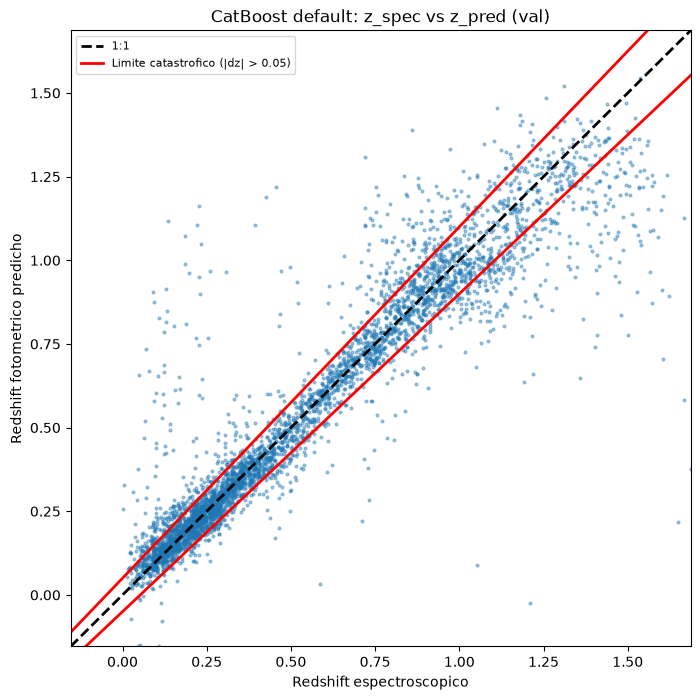

In [12]:
plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_default,
    title="CatBoost default: z_spec vs z_pred (val)"
)
plt.show()

## Optimizacion de hiperparametros con Optuna

Se usa cross-validation de 5 folds **solo sobre el conjunto de train**.
El conjunto de validacion se usa despues para evaluar y calcular PFI.

In [13]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-2, 10.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
    }

    model = CatBoostRegressor(
        **params,
        random_seed=42,
        verbose=0,
    )

    # cat_features se pasa via params (metadata routing) porque cross_val_score
    # usa clone() internamente, y CatBoost modifica cat_features
    # en su constructor, lo que hace fallar a clone().
    scores = cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        params={"cat_features": cat_features_idx},
    )
    return -scores.mean()

In [15]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=-1)

best_params = study.best_params
print(f"Mejor MSE (CV): {study.best_value:.6f}")
print(f"Mejores hiperparametros: {best_params}")

Best trial: 45. Best value: 0.017681: 100%|██████████| 50/50 [29:50<00:00, 35.81s/it]  

Mejor MSE (CV): 0.017681
Mejores hiperparametros: {'iterations': 1158, 'learning_rate': 0.02631638456289962, 'depth': 10, 'l2_leaf_reg': 0.011074087230529862, 'bagging_temperature': 0.42703982392759743, 'random_strength': 0.1334760027217455, 'min_data_in_leaf': 22}


In [16]:
# Entrenar con los mejores hiperparametros y evaluar en val
cb_opt = CatBoostRegressor(
    **best_params,
    cat_features=cat_features_idx,
    random_seed=42,
    verbose=0,
)

cb_opt.fit(X_train, y_train)
y_pred_opt = cb_opt.predict(X_val)

results["CatBoost optimizado"] = evaluate_regression(
    y_val.to_numpy(), y_pred_opt, "CatBoost optimizado"
)

--- CatBoost optimizado ---
MAE:       0.06622
MSE:       0.01638
RMSE:      0.12798
R2:        0.89249
bias(dz):  0.00488
std(dz):   0.08065
sigma_MAD: 0.03204
eta [%]:   22.217



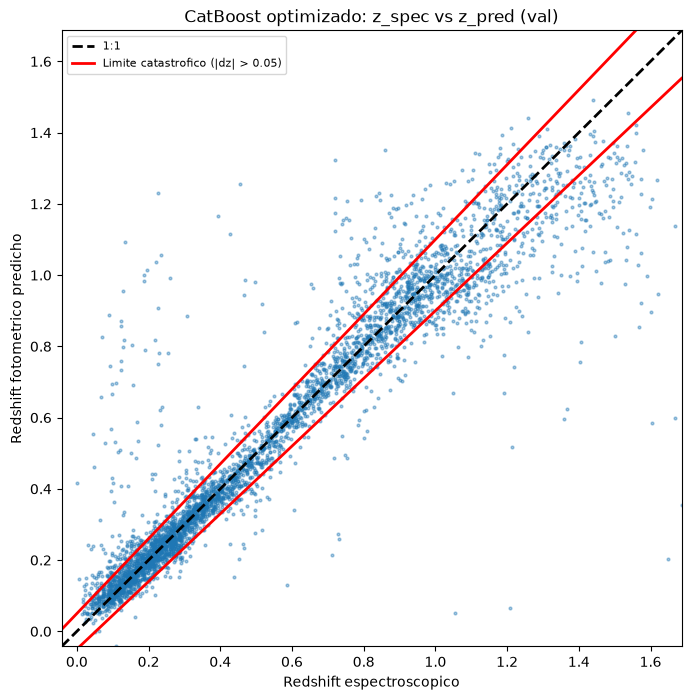

In [17]:
plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_opt,
    title="CatBoost optimizado: z_spec vs z_pred (val)"
)
plt.show()

## Interpretabilidad: Feature Importance y PFI sobre modelo optimizado

PFI se calcula sobre el conjunto de **validacion**, no sobre test.

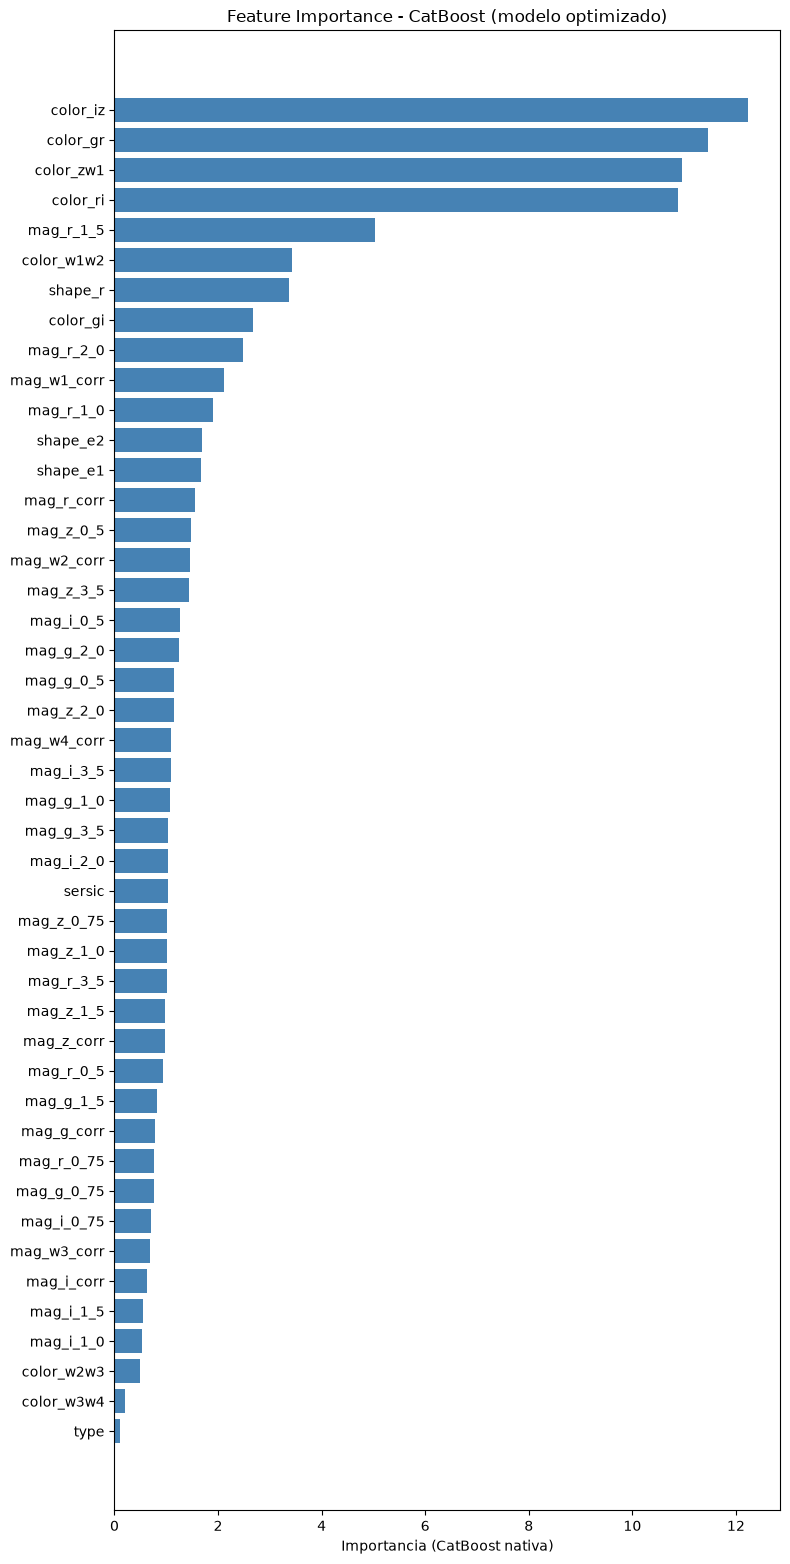

In [18]:
# Feature importance nativa de CatBoost
importances = cb_opt.get_feature_importance()
feature_names = X.columns.tolist()

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(imp_df))))
plt.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (CatBoost nativa)")
plt.title("Feature Importance - CatBoost (modelo optimizado)")
plt.tight_layout()
plt.show()

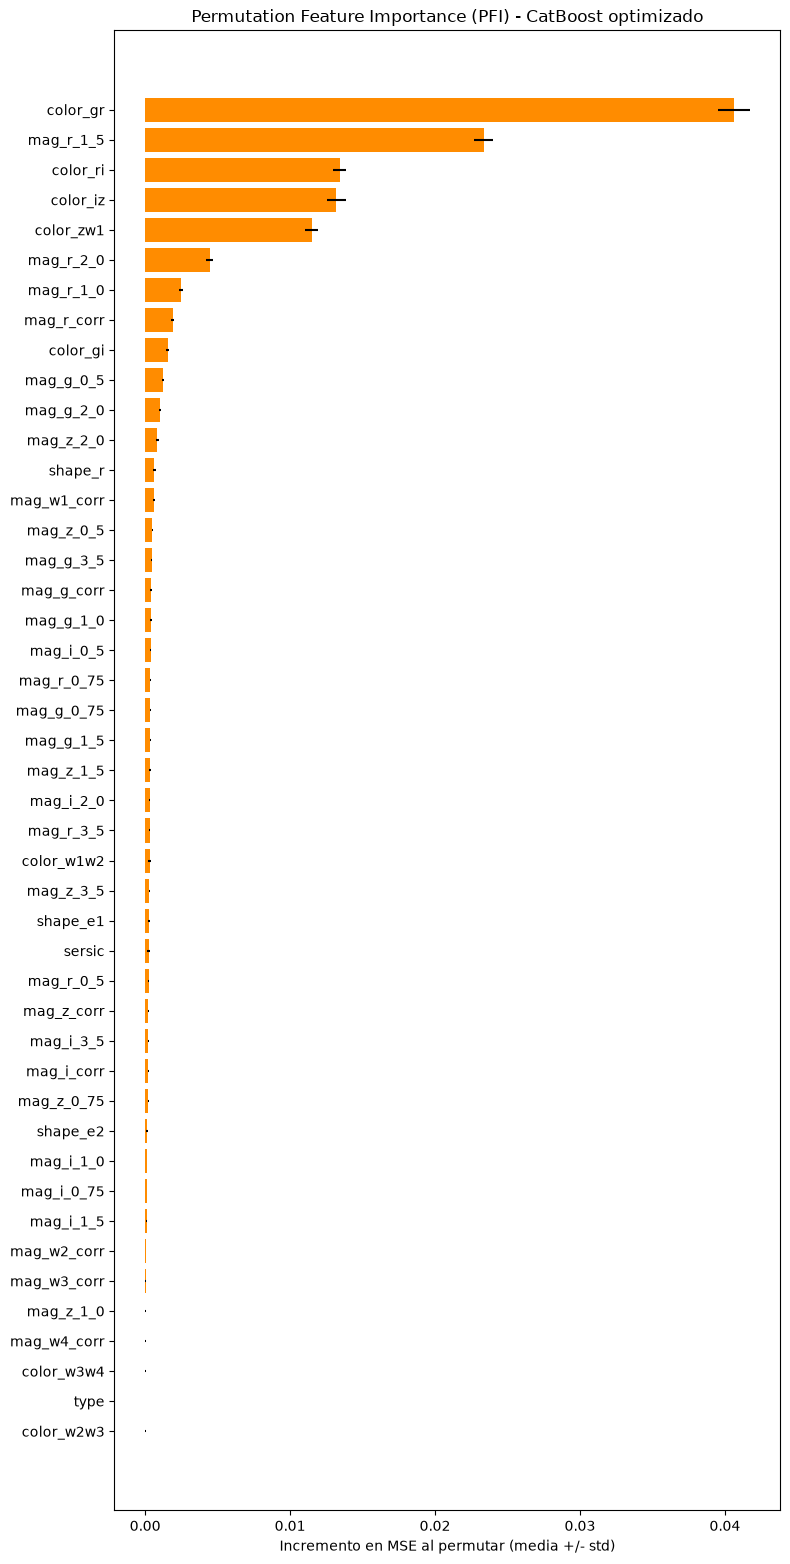

,feature,importance_mean,importance_std
38,color_gr,0.040606,0.001107
22,mag_r_1_5,0.023359,0.000647
39,color_ri,0.013415,0.000473
40,color_iz,0.013176,0.000649
41,color_zw1,0.011507,0.000447
23,mag_r_2_0,0.004441,0.000245
21,mag_r_1_0,0.002468,0.000145
6,mag_r_corr,0.001903,0.000116
37,color_gi,0.001563,0.000103
13,mag_g_0_5,0.001256,0.000077


In [19]:
# Permutation Feature Importance (PFI) sobre conjunto de validacion
pfi_result = permutation_importance(
    cb_opt,
    X_val,
    y_val,
    scoring="neg_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

pfi_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(pfi_df))))
plt.barh(
    pfi_df["feature"],
    pfi_df["importance_mean"],
    xerr=pfi_df["importance_std"],
    color="darkorange",
)
plt.gca().invert_yaxis()
plt.xlabel("Incremento en MSE al permutar (media +/- std)")
plt.title("Permutation Feature Importance (PFI) - CatBoost optimizado")
plt.tight_layout()
plt.show()

pfi_df

## Seleccion de features y re-entrenamiento

Se descartan features con PFI negativa o nula.

In [20]:
# Features con PFI positiva
selected_features = pfi_df[pfi_df["importance_mean"] > 0]["feature"].tolist()

dropped = [f for f in X.columns if f not in selected_features]
print(f"Features seleccionadas: {len(selected_features)} de {X.shape[1]}")
print(f"Features descartadas: {dropped}")

Features seleccionadas: 45 de 45
Features descartadas: []


In [21]:
# Recalcular indices de features categoricas para el subset
cat_idx_sel = [selected_features.index(c) for c in cat_feature_names if c in selected_features]

cb_selected = CatBoostRegressor(
    **best_params,
    cat_features=cat_idx_sel if cat_idx_sel else None,
    random_seed=42,
    verbose=0,
)

cb_selected.fit(X_train[selected_features], y_train)
y_pred_sel = cb_selected.predict(X_val[selected_features])

results["CatBoost opt + PFI"] = evaluate_regression(
    y_val.to_numpy(), y_pred_sel, "CatBoost optimizado + features PFI"
)

--- CatBoost optimizado + features PFI ---
MAE:       0.06635
MSE:       0.01638
RMSE:      0.12800
R2:        0.89245
bias(dz):  0.00475
std(dz):   0.08046
sigma_MAD: 0.03190
eta [%]:   21.630



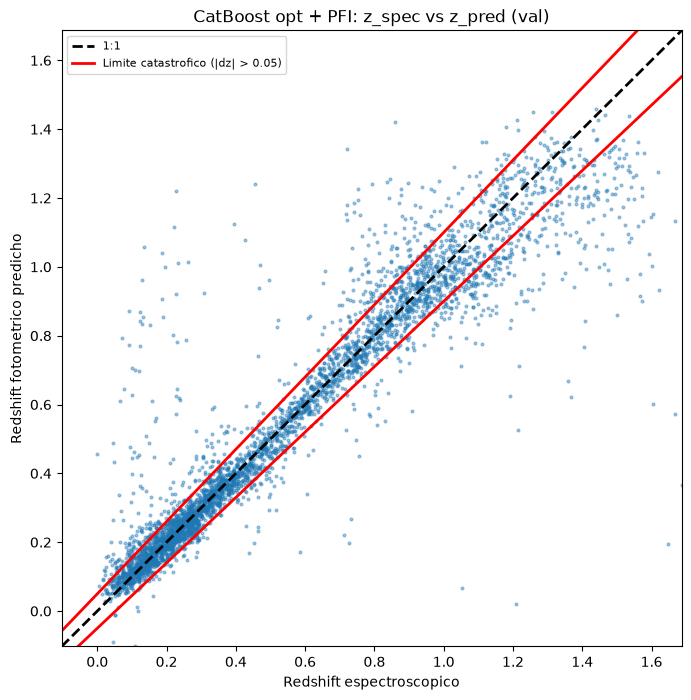

In [22]:
plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_sel,
    title="CatBoost opt + PFI: z_spec vs z_pred (val)"
)
plt.show()

## Comparacion de modelos (evaluados en val)

In [23]:
comparison = pd.DataFrame(results).T
comparison

,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
Dummy (media),0.337682,0.152331,0.390297,-0.000003,0.059850,0.244602,0.321668,91.968060
CatBoost default,0.072024,0.017495,0.132269,0.885151,0.004987,0.083448,0.037826,25.481447
CatBoost optimizado,0.066217,0.016378,0.127975,0.892486,0.004880,0.080651,0.032042,22.217003
CatBoost opt + PFI,0.066345,0.016384,0.127999,0.892446,0.004754,0.080461,0.031904,21.629873


## Evaluacion final en test

**Ejecutar solo cuando el modelo este definido.**
Elegir el mejor modelo segun la tabla anterior y evaluarlo en test una sola vez.

In [24]:
# Elegir el modelo final (cambiar segun la comparacion anterior)
# Opcion 1: cb_opt (todas las features)
# Opcion 2: cb_selected (features PFI)

final_model = cb_selected
final_features = selected_features  # None si se usa cb_opt con todas las features

if final_features is not None:
    y_pred_test = final_model.predict(X_test[final_features])
else:
    y_pred_test = final_model.predict(X_test)

results_test = evaluate_regression(
    y_test.to_numpy(), y_pred_test, "Modelo final (test)"
)

--- Modelo final (test) ---
MAE:       0.06698
MSE:       0.01779
RMSE:      0.13337
R2:        0.88596
bias(dz):  0.00516
std(dz):   0.08734
sigma_MAD: 0.03088
eta [%]:   20.597



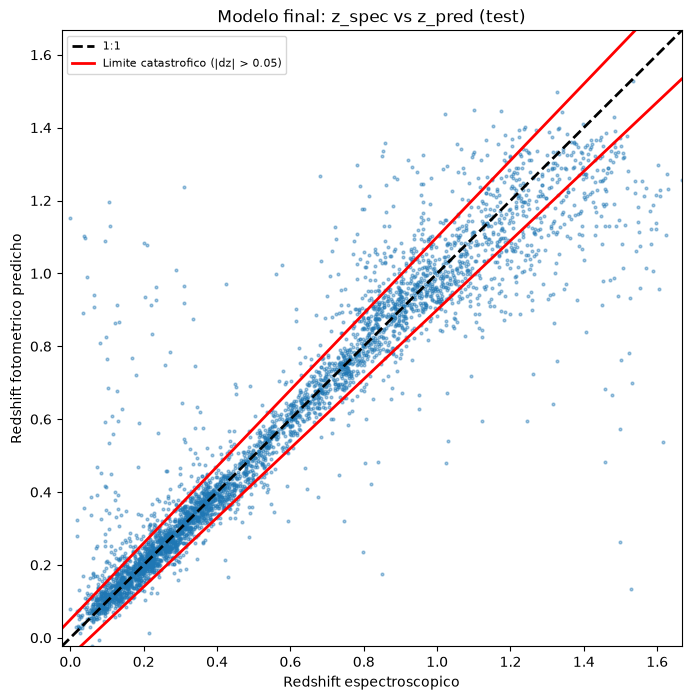

In [25]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred_test,
    title="Modelo final: z_spec vs z_pred (test)"
)
plt.show()